<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-08-31 13:55:18--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  11.7MB/s    in 15s     

2026-08-31 13:55:33 (10.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [4]:
# The compensation is highly skewed due to high outliers
df["ConvertedCompYearly"].max()

np.float64(16256603.0)

In [5]:
# Let's check the quartiles
df["ConvertedCompYearly"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900     167000.000
0.950     210000.000
0.990     393751.060
0.995     540000.000
0.999    1301594.422
Name: ConvertedCompYearly, dtype: float64

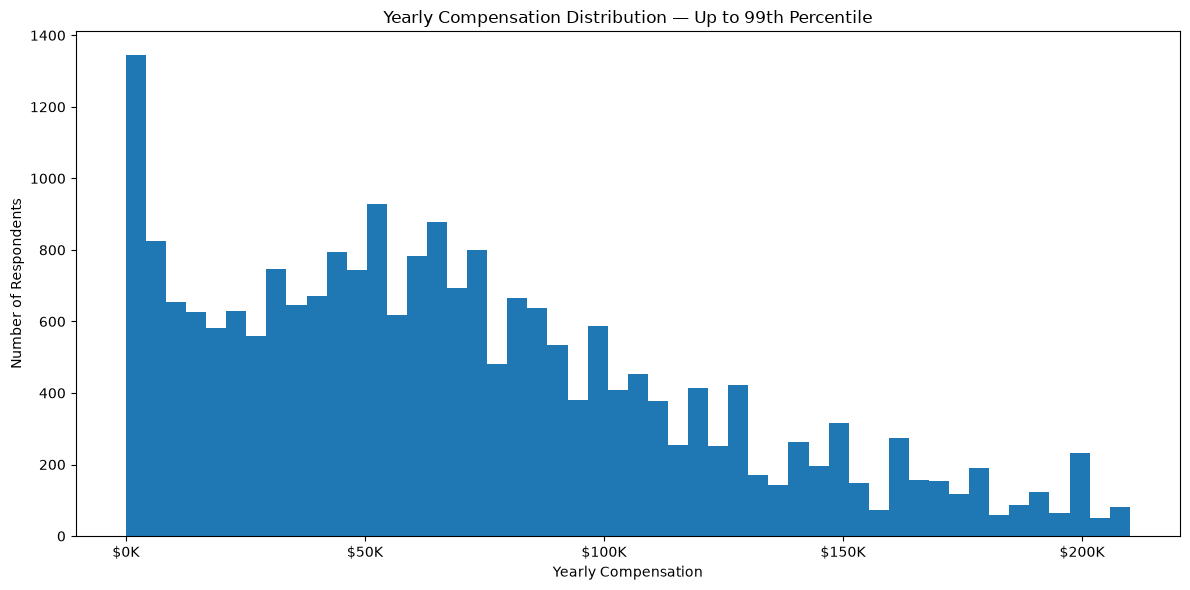

In [15]:
# For a cleaner visualization I'll use 0.95 quartile
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

upper_limit = df["ConvertedCompYearly"].quantile(0.95)

plt.figure(figsize=(12, 6))

plt.hist(
    df.loc[
        df["ConvertedCompYearly"] <= upper_limit,
        "ConvertedCompYearly"
    ].dropna(),
    bins=50
)

plt.title("Yearly Compensation Distribution — Up to 99th Percentile")
plt.xlabel("Yearly Compensation")
plt.ylabel("Number of Respondents")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x/1_000_000:.1f}M"
        if x >= 1_000_000
        else f"${x/1_000:.0f}K"
    )
)

plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [8]:
# Checking Age categories
df["Age"].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [9]:
# First let's update the Age categories from shorter names as we've done in previous assessemnts
# Let's update the Age Groups as we've done in previous assessments
age_mapping = {
    "Under 18 years old": "<18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

df["Age"] = df["Age"].replace(age_mapping)

In [10]:
# Now Let's convert Age groups in numerical values
age_mapping = {
    "<18": 17,
    "18-24": 21,
    "25-34": 29.5,
    "35-44": 39.5,
    "45-54": 49.5,
    "55-64": 59.5,
    "65+": 65
}

df["AgeNumeric"] = df["Age"].map(age_mapping)

In [11]:
# Let's check the result
df[["Age", "AgeNumeric"]].head(10)

,Age,AgeNumeric
0,<18,17.0
1,35-44,39.5
2,45-54,49.5
3,18-24,21.0
4,18-24,21.0
5,<18,17.0
6,35-44,39.5
7,18-24,21.0
8,45-54,49.5
9,35-44,39.5


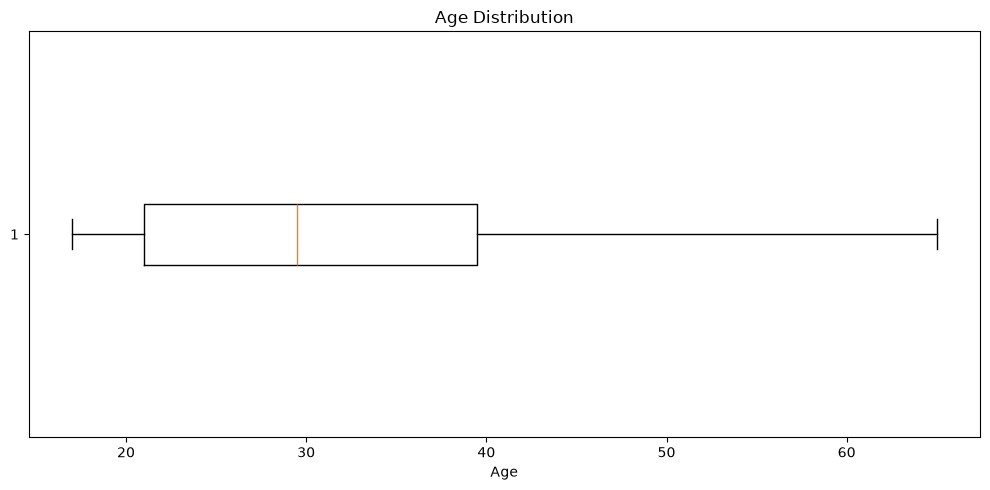

In [13]:
# Now let's create the boxplot 
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["AgeNumeric"].dropna(),
    orientation="horizontal"
)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



In [14]:
# Let's create a clean dataset for our analysis
scatter_df = df[
    ["AgeNumeric", "ConvertedCompYearly"]
].dropna()

In [16]:
# For a cleaner view I'll upperlimite to 0.95 quartile
upper_limit = df["ConvertedCompYearly"].quantile(0.99)

scatter_df = df[
    (df["AgeNumeric"].notna()) &
    (df["ConvertedCompYearly"].notna()) &
    (df["ConvertedCompYearly"] <= upper_limit)
]

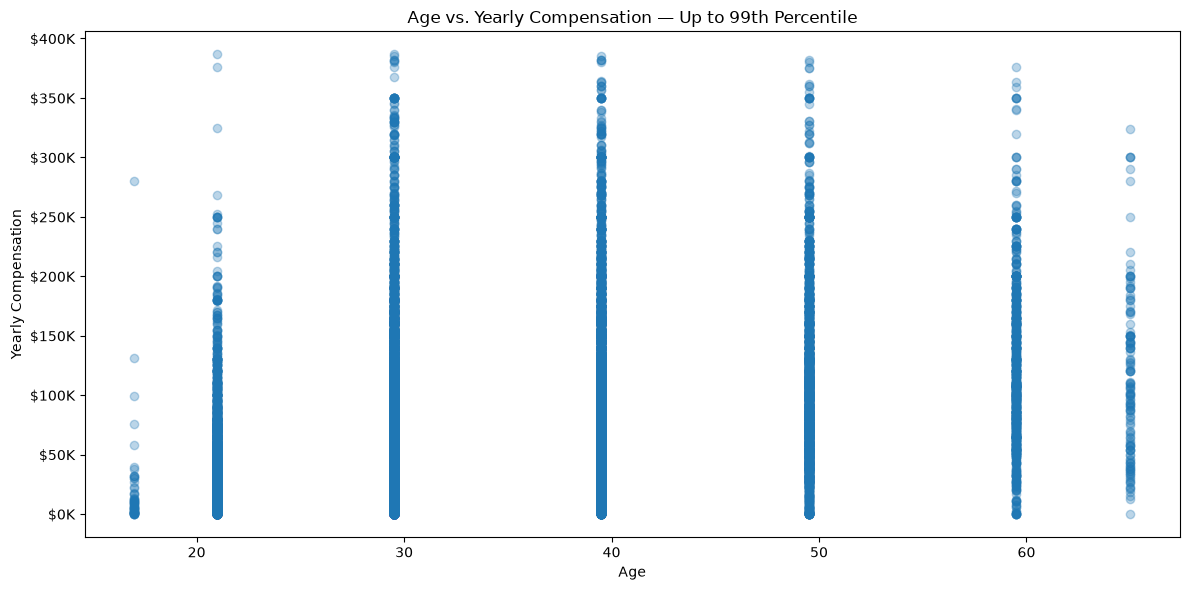

In [17]:
# Visualizing chart
plt.figure(figsize=(12, 6))

plt.scatter(
    scatter_df["AgeNumeric"],
    scatter_df["ConvertedCompYearly"],
    alpha=0.3
)

plt.title("Age vs. Yearly Compensation — Up to 99th Percentile")
plt.xlabel("Age")
plt.ylabel("Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x/1_000_000:.1f}M"
        if x >= 1_000_000
        else f"${x/1_000:.0f}K"
    )
)

plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [18]:
# Let's create a clean dataset
bubble_df = df[
    ["ConvertedCompYearly", "JobSatPoints_6", "AgeNumeric"]
].dropna()

upper_limit = bubble_df["ConvertedCompYearly"].quantile(0.99)

bubble_df = bubble_df[
    bubble_df["ConvertedCompYearly"] <= upper_limit
]

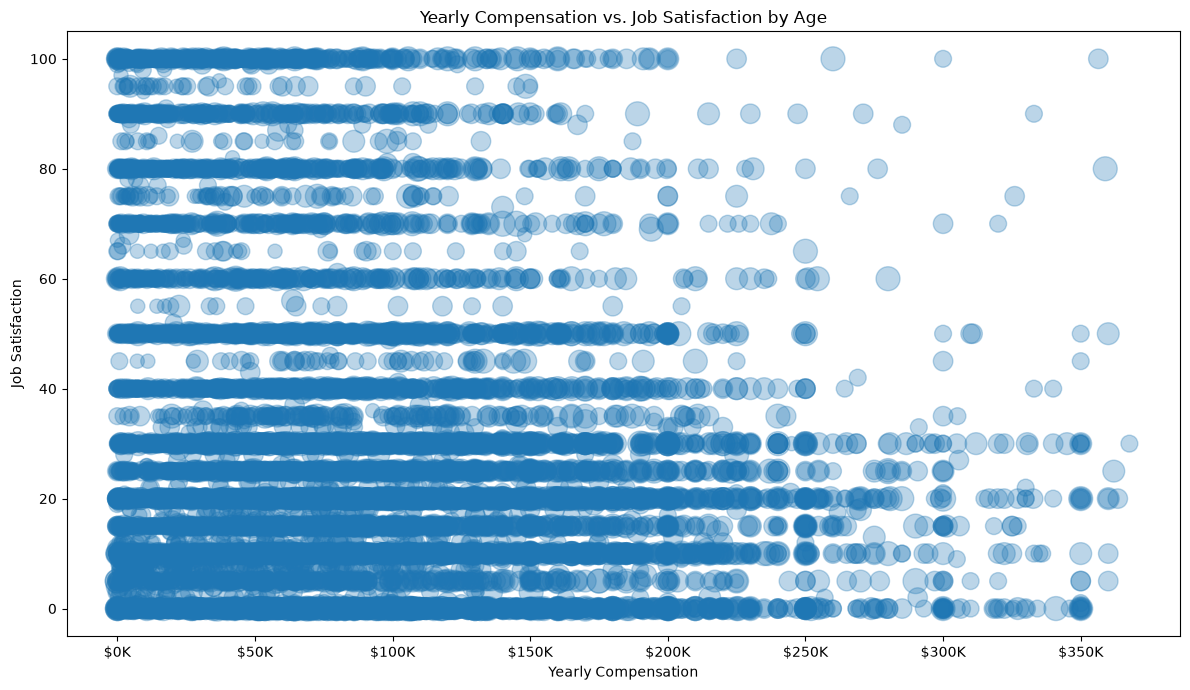

In [20]:
# Visualizing chart
plt.figure(figsize=(12, 7))

plt.scatter(
    bubble_df["ConvertedCompYearly"],
    bubble_df["JobSatPoints_6"],
    s=bubble_df["AgeNumeric"] * 5,
    alpha=0.3
)

plt.title(
    "Yearly Compensation vs. Job Satisfaction by Age"
)
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x/1_000_000:.1f}M"
        if x >= 1_000_000
        else f"${x/1_000:.0f}K"
    )
)

plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



In [21]:
# Let's count the MainBranch categories
main_branch_counts = df["MainBranch"].value_counts()

main_branch_counts

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64

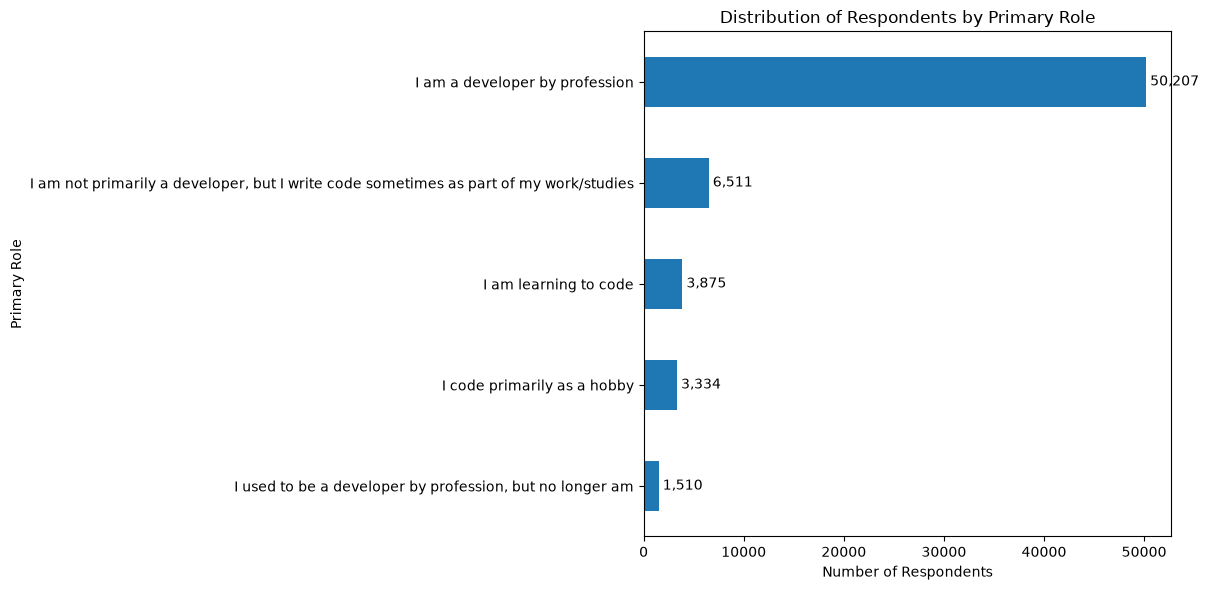

In [23]:
# Create a horizontal bar chart
plt.figure(figsize=(12, 6))

main_branch_sorted = main_branch_counts.sort_values()

ax = main_branch_sorted.plot(
    kind="barh"
)

plt.title("Distribution of Respondents by Primary Role")
plt.xlabel("Number of Respondents")
plt.ylabel("Primary Role")

for i, value in enumerate(main_branch_sorted):
    ax.text(
        value,
        i,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



In [ ]:
## Write your code here

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


In [ ]:
## Write your code here

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



In [27]:
# Let's count the languages and get the top 10
language_counts = (
    df["LanguageWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .value_counts()
)

top_10_languages = language_counts.head(10)
top_10_languages

LanguageWantToWorkWith
Python                     25047
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Name: count, dtype: int64

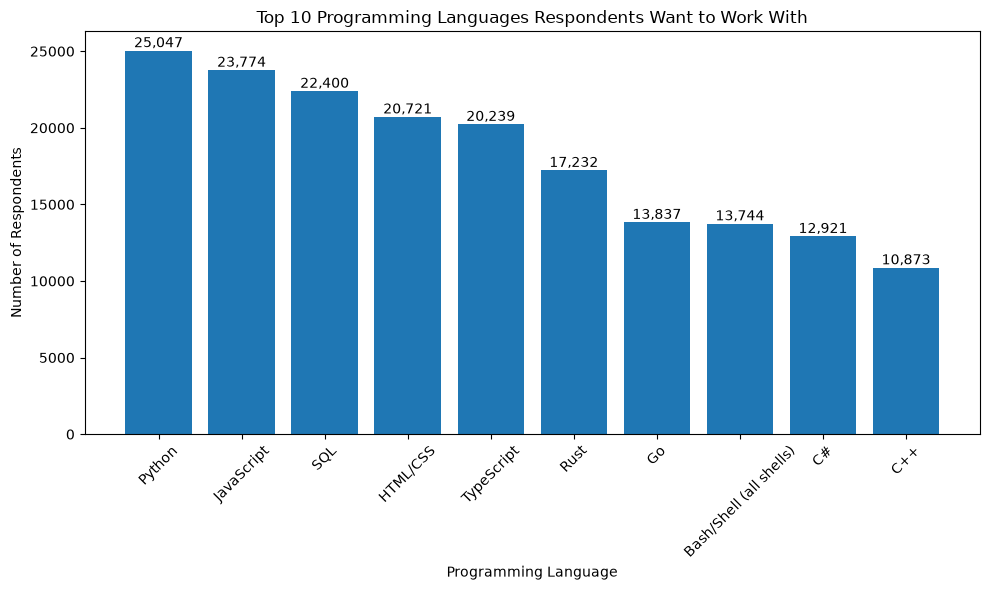

In [29]:
# Let's visualize a vertical bar with labels
plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_10_languages.index,
    top_10_languages.values
)

plt.title("Top 10 Programming Languages Respondents Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



In [31]:
# Let's define the Age order
age_order = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65 years or older"
]

# Calculate median compensation
median_comp_by_age = (
    df.dropna(subset=["Age", "ConvertedCompYearly"])
      .groupby("Age")["ConvertedCompYearly"]
      .median()
      .reindex(age_order)
)

median_comp_by_age

Age
Under 18                  NaN
18-24                 25000.0
25-34                 59825.0
35-44                 84796.0
45-54                 99099.0
55-64                109691.0
65 years or older         NaN
Name: ConvertedCompYearly, dtype: float64

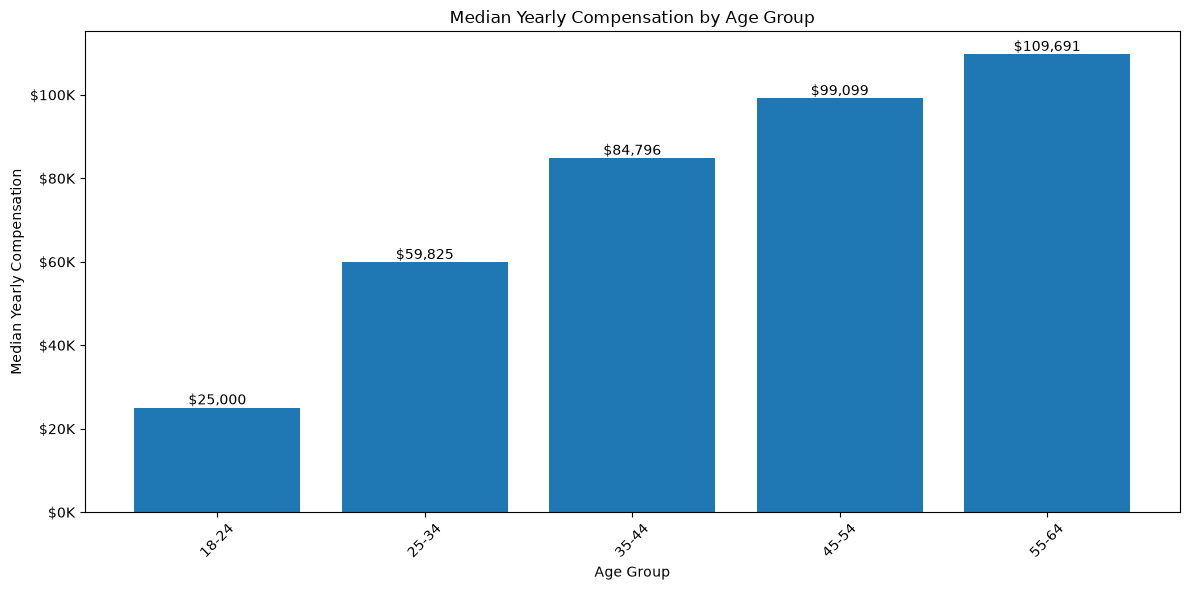

In [32]:
# Visualize the bar chart
plt.figure(figsize=(12, 6))

bars = plt.bar(
    median_comp_by_age.index,
    median_comp_by_age.values
)

plt.title("Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x/1_000:.0f}K"
        if x < 1_000_000
        else f"${x/1_000_000:.1f}M"
    )
)

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



In [33]:
# Count respondents by Country
country_counts = df["Country"].value_counts()

country_counts.head(10)

Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Name: count, dtype: int64

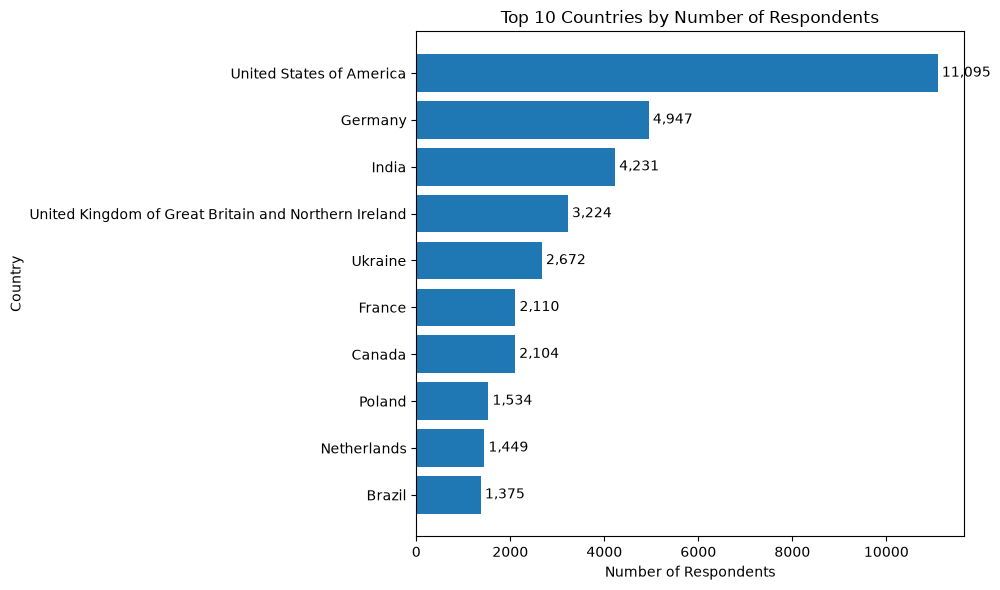

In [34]:
# Visualizing Bar chart
top_countries = country_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title("Top 10 Countries by Number of Respondents")
plt.xlabel("Number of Respondents")
plt.ylabel("Country")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
